In [13]:
import pandas as pd
import os.path as op
import numpy as np
from os import listdir
#import pingouin
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('talk')
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.25, palette='tab10')

bids_folder_behav ='/Users/mrenke/data/ds-stressrisk'
plot_folder_path = '/Users/mrenke/Desktop/StressRisk/figures/plots/fig_4'

#import arviz as az
#def get_hdi(d, ci=0.95):
#    return az.hdi(d.values, hdi_prob=ci)

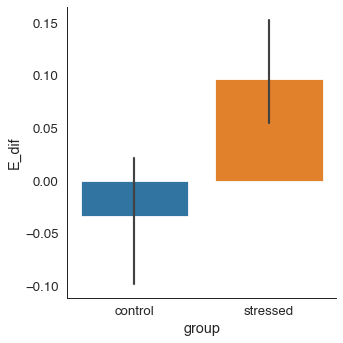

In [16]:
# E_diff
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')


Es_within = pd.read_csv(op.join(bids_folder_behav, 'interim_sum_data', 'within_ses_decodedE.csv'))
Es_across = pd.read_csv(op.join(bids_folder_behav, 'interim_sum_data','across_ses_decodedE.csv'))

Es_within = Es_within.set_index(['subject', 'trial_nr', 'session']).rename(mapper={'E':'E_w', 'sd':'sd_w'}, axis=1).xs(2,0,'session')
Es_across = Es_across.set_index(['subject', 'trial_nr']).rename(mapper={'E':'E_a', 'sd':'sd_a'}, axis=1)

from stress_risk.utils.data import add_cond2df
Es = Es_within.join(Es_across).set_index('risky_first', append=True)
Es = add_cond2df(Es)
Es['E_dif'] = Es['E_a'] - Es['E_w']

temp = Es.groupby(['subject']).mean()
temp['group_name'] = np.where(temp['group'] == 0, 'control', 'stressed')

sns.catplot(data=temp.reset_index(), x='group_name', y='E_dif',  kind='bar') #kind='bar',,errorbar=get_hdi
plt.xlabel('group')
plt.savefig(op.join(plot_folder_path, 'E_diff_catplot-groups.pdf'), bbox_inches='tight')

In [10]:
Es

E_w      sd_w       E_a      sd_a    n1  \
subject trial_nr risky_first                                                 
2       1        False        3.630729  0.237235  3.227458  0.480335  10.0   
                 False        3.630729  0.237235  3.227458  0.480335  10.0   
        2        False        3.215811  0.250970  3.158594  0.693151  14.0   
                 False        3.215811  0.250970  3.158594  0.693151  14.0   
        3        False        3.268363  0.630426  3.231419  0.480769  14.0   
...                                ...       ...       ...       ...   ...   
61      118      True         3.930218  0.220174  2.644663  0.140344  34.0   
        119      True         1.928028  0.033986  2.436559  0.227761  34.0   
                 True         1.928028  0.033986  2.436559  0.227761  34.0   
        120      True         4.440225  0.185782  3.617215  0.254384  42.0   
                 True         4.440225  0.185782  3.617215  0.254384  42.0   

                              group    log_n1 group_name     E_dif  
subject trial_nr risky_first                                        
2       1        False            0  2.302585    control -0.403270  
                 False            0  2.302585    control -0.403270  
        2        False            0  2.639057    control -0.057217  
                 False            0  2.639057    control -0.057217  
        3        False            0  2.639057    control -0.036944  
...                             ...       ...        ...       ...  
61      118      True             0  3.526361    control -1.285555  
        119      True             0  3.526361    control  0.508531  
                 True             0  3.526361    control  0.508531  
        120      True             0  3.737670    control -0.823009  
                 True             0  3.737670    control -0.823009  

[11651 rows x 9 columns]

In [4]:
import pingouin
pingouin.anova(data=Es.reset_index(), dv='E_dif', between='group')


,Source,ddof1,ddof2,F,p-unc,np2
0,group,1,11649,86.256889,1.859090e-20,0.00735


/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [5]:
Es

E_w      sd_w       E_a      sd_a    n1  \
subject trial_nr risky_first                                                 
2       1        False        3.630729  0.237235  3.227458  0.480335  10.0   
                 False        3.630729  0.237235  3.227458  0.480335  10.0   
        2        False        3.215811  0.250970  3.158594  0.693151  14.0   
                 False        3.215811  0.250970  3.158594  0.693151  14.0   
        3        False        3.268363  0.630426  3.231419  0.480769  14.0   
...                                ...       ...       ...       ...   ...   
61      118      True         3.930218  0.220174  2.644663  0.140344  34.0   
        119      True         1.928028  0.033986  2.436559  0.227761  34.0   
                 True         1.928028  0.033986  2.436559  0.227761  34.0   
        120      True         4.440225  0.185782  3.617215  0.254384  42.0   
                 True         4.440225  0.185782  3.617215  0.254384  42.0   

                              group    log_n1 group_name     E_dif  
subject trial_nr risky_first                                        
2       1        False            0  2.302585    control -0.403270  
                 False            0  2.302585    control -0.403270  
        2        False            0  2.639057    control -0.057217  
                 False            0  2.639057    control -0.057217  
        3        False            0  2.639057    control -0.036944  
...                             ...       ...        ...       ...  
61      118      True             0  3.526361    control -1.285555  
        119      True             0  3.526361    control  0.508531  
                 True             0  3.526361    control  0.508531  
        120      True             0  3.737670    control -0.823009  
                 True             0  3.737670    control -0.823009  

[11651 rows x 9 columns]